# Climate Change Trends Using NASA Satellite Data by Denzel Jacob

# What is climate change?
Climate change refers to long-term shifts in temperatures and weather patterns. The proposed effects of climate change are land and ocean temperature increases, frequency and severity changes in extreme weather, precipitation variation, and vegetation cover changes.I will be using NASA's POWER project data specifically their MERRA-2 dataset which is updated weekly. I will be looking at 6 metrics over the course of 40 years, these metrics are earth skin temperature, precipitation, total column precipitable water, profile soil moisture, temperature at 2 meters, and temperature at 10 meters. I will analyze data relevant to the contiguous United States for this project.There are some limitations to my analysis and I will go over them at the end.

Step 1: import necessary python modules and set the start and end dates

In [1]:
import os
import fsspec
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from datetime import datetime
import ipywidgets as widgets
from IPython.display import display
import numpy as np
from scipy.stats import linregress


start_date = datetime(1984, 1, 1) # 1984 - 2024 (40 years)
end_date = datetime(2024, 12, 31)

# NOTE: May need to pip install missing modules

Step 2: Fetch data file from NASA POWER's AWS s3 bucket using their S3 Mountpoint.

In [2]:


filepath = 'https://nasa-power.s3.amazonaws.com/merra2/temporal/power_merra2_monthly_temporal_utc.zarr/'
filepath_mapped = fsspec.get_mapper(filepath)
ds = xr.open_zarr(filepath_mapped, consolidated=True)
ds

,Array,Chunk
Bytes,466.41 MiB,2.02 MiB
Shape,"(588, 361, 576)","(588, 30, 30)"
Count,261 Tasks,260 Chunks
Type,float32,numpy.ndarray
,Array,Chunk
Bytes,466.41 MiB,2.02 MiB
Shape,"(588, 361, 576)","(588, 30, 30)"
Count,261 Tasks,260 Chunks
Type,float32,numpy.ndarray
,Array,Chunk


Step 3: Extract the data sets for the aforemetioned metrics, then convert them to a pandas dataframe. Finally export the dataframes as .csv files for quick access.

In [3]:
'''
The latitude range for the contiguous United States is roughly 25°N to 49°N, 
while the longitude range is roughly 67°W to 125°W
'''



ds_temp =  ds.TS.sel(time=pd.date_range(start_date, end_date, freq='3M')).load()
ds_T2M = ds.T2M.sel(time=pd.date_range(start_date, end_date, freq='3M')).load()
ds_T10M =ds.T10M.sel(time=pd.date_range(start_date, end_date, freq='3M')).load()
ds_prec = ds.PRECTOTCORR_SUM.sel(time=pd.date_range(start_date,end_date, freq='3M')).load()
ds_col_prec = ds.TQV.sel(time=pd.date_range(start_date, end_date, freq='3M')).load()
ds_wet_prof = ds.GWETPROF.sel(time=pd.date_range(start_date, end_date, freq='3M')).load()

# dataArray to pandas Dataframe
ds_temp = ds_temp.to_dataframe() 
ds_prec = ds_prec.to_dataframe()
ds_col_prec = ds_col_prec.to_dataframe() 
ds_wet_prof = ds_wet_prof.to_dataframe()
ds_T2M = ds_T2M.to_dataframe()
ds_T10M = ds_T10M.to_dataframe()

#write to CSV to cache for faster access
output = r''

ds_temp.to_csv(os.path.join(output, "temp.csv"))
ds_prec.to_csv(os.path.join(output, "precipitation.csv"))
ds_col_prec.to_csv(os.path.join(output, "col_precipitable.csv"))
ds_wet_prof.to_csv(os.path.join(output, "moisture_profile.csv"))
ds_T2M.to_csv(os.path.join(output, "temp2meter.csv"))
ds_T10M.to_csv(os.path.join(output, "temp10meter.csv"))

             

In [4]:
ds_temp.groupby(['time']).count()


,TS
time,
1984-01-31,207936
1984-04-30,207936
1984-07-31,207936
1984-10-31,207936
1985-01-31,207936
...,...
2023-10-31,207936
2024-01-31,207936
2024-04-30,207936


Step 4: Read the raw data into their own corrosponding dataframes, then proceed with a left merge using the 'lat','long',and 'time' keys on all the dataframes to create a master dataframe. Then clean and transform the data into the desired format and export to a new .csv file.

In [5]:

imperial = True # imperial units toggle


df_temp = pd.read_csv('temp.csv', sep=',' , header = 0, names= ['time','lat','long','earth_skin_temp'])
df_prec = pd.read_csv('precipitation.csv', sep=',' , header = 0, names= ['time','lat','long','precipitation'])
df_col_prec = pd.read_csv('col_precipitable.csv', sep=',' , header = 0, names= ['time','lat','long','total_column_precipitable_water'])
df_wet_prof = pd.read_csv('moisture_profile.csv', sep=',' , header = 0, names= ['time','lat','long','profile_soil_moisture'])
df_T2M = pd.read_csv('temp2meter.csv', sep=',' , header = 0, names= ['time','lat','long','temp_2_meter'])
df_T10M = pd.read_csv('temp10meter.csv', sep=',' , header = 0, names= ['time','lat','long','temp_10_meter'])



df = pd.merge(df_temp,df_prec, how = "left", on = ['lat','long','time']) # merge on 3 three keys
df = pd.merge(df,df_col_prec, how = "left", on = ['lat','long','time'])
df = pd.merge(df,df_wet_prof, how = "left", on = ['lat','long','time'])
df = pd.merge(df,df_T2M, how = "left", on = ['lat','long','time'])
df = pd.merge(df,df_T10M, how = "left", on = ['lat','long','time'])


df = df.dropna(subset=['profile_soil_moisture']) # drop NaN (does not have a soil moisture level)

df = df[df['lat'].between(25,49) & df['long'].between (-125,-67)] # filter for USA minus alaska area

if(imperial):
    df['earth_skin_temp'] =  (df['earth_skin_temp']*(9/5)) + 32 # convert to fahrenheit
    df['temp_2_meter'] =  (df['temp_2_meter']*(9/5)) + 32 
    df['temp_10_meter'] =  (df['temp_10_meter']*(9/5)) + 32 
    

    
df.to_csv('cleaned_data.csv', index=False)   
df



,time,lat,long,earth_skin_temp,precipitation,total_column_precipitable_water,profile_soil_moisture,temp_2_meter,temp_10_meter
132588,1984-01-31,25.0,-112.500,68.270043,26.369995,15.130005,0.369995,66.307996,66.307996
132589,1984-01-31,25.0,-111.875,64.687951,39.659973,14.830017,0.409973,63.823987,64.670043
132590,1984-01-31,25.0,-111.250,64.021960,35.549988,13.960022,0.400024,63.013964,63.842004
132591,1984-01-31,25.0,-110.625,69.295946,27.299988,15.919983,0.419983,67.136036,67.405969
132592,1984-01-31,25.0,-110.000,71.510022,31.299988,17.700012,0.409973,69.439978,69.278040
...,...,...,...,...,...,...,...,...,...
34053872,2024-10-31,49.0,-70.000,41.018018,49.330017,12.969971,0.320007,41.197974,41.450000
34053873,2024-10-31,49.0,-69.375,41.989978,78.770020,13.909973,0.419983,42.079956,42.439978
34053874,2024-10-31,49.0,-68.750,44.510022,118.900024,15.140015,0.500000,44.347974,44.815991
34053875,2024-10-31,49.0,-68.125,46.112049,135.719970,15.669983,0.549988,45.770044,46.202026


Step  5: Load the readied data from the prepared .csv file into a dataframe. 

In [7]:

# After Step 5 is complete and the cleaned data is stored on your system you may 
# quickly access the cached data by running step 1 and step 5
df = pd.read_csv('cleaned_data.csv', sep=',' , header = 0, names= ['time','lat','long','earth_skin_temp','precipitation','total_column_precipitable_water','profile_soil_moisture','temp_2_meter','temp_10_meter'])
df 

,time,lat,long,earth_skin_temp,precipitation,total_column_precipitable_water,profile_soil_moisture,temp_2_meter,temp_10_meter
0,1984-01-31,25.0,-112.500,68.270043,26.369995,15.130005,0.369995,66.307996,66.307996
1,1984-01-31,25.0,-111.875,64.687951,39.659973,14.830017,0.409973,63.823987,64.670043
2,1984-01-31,25.0,-111.250,64.021960,35.549988,13.960022,0.400024,63.013964,63.842004
3,1984-01-31,25.0,-110.625,69.295946,27.299988,15.919983,0.419983,67.136036,67.405969
4,1984-01-31,25.0,-110.000,71.510022,31.299988,17.700012,0.409973,69.439978,69.278040
...,...,...,...,...,...,...,...,...,...
578587,2024-10-31,49.0,-70.000,41.018018,49.330017,12.969971,0.320007,41.197974,41.450000
578588,2024-10-31,49.0,-69.375,41.989978,78.770020,13.909973,0.419983,42.079956,42.439978
578589,2024-10-31,49.0,-68.750,44.510022,118.900024,15.140015,0.500000,44.347974,44.815991
578590,2024-10-31,49.0,-68.125,46.112049,135.719970,15.669983,0.549988,45.770044,46.202026


Step 6: Perform analysis and vizualize the data using the matplotlib and scipy python modules. Use ipywidgets to aid in visualizations. It is recommended to run and view one metric's heatmap and regression model at a time.

# 




# What is "Earth Skin Temperature"?

Earth skin temperature, also known as land surface temperature or LST, is defined as the temperature of the topmost layer of the earth's crust. The temperature of the land may influence the temperature of the air mass directly above it. If there is a trend of increasing LST over the years this may lead to increaseing air temperatures as well.

<IPython.core.display.Javascript object>


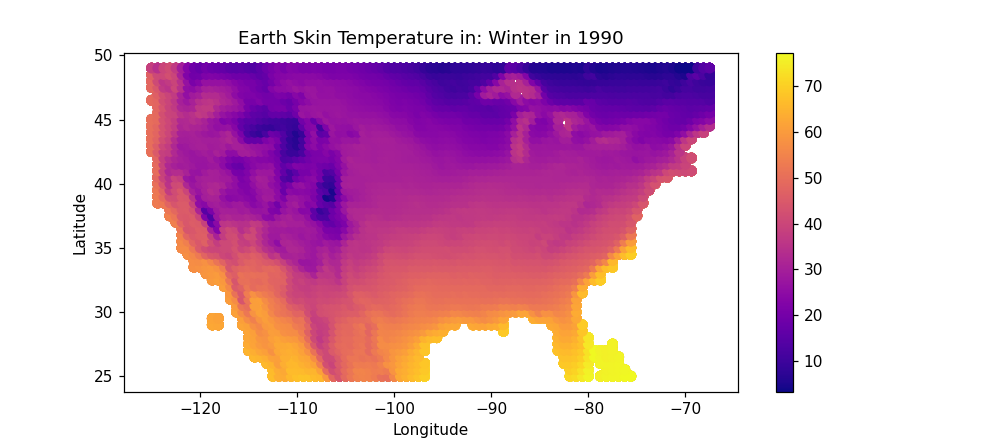

interactive(children=(IntSlider(value=1, description='Season:', max=4, min=1), IntSlider(value=1984, descripti…

In [8]:


#allows interactive widgets
%matplotlib nbagg

df_winter=df[df['time'] == '2020-01-31'] # for all 4 seasons
df_spring=df[df['time'] == '2020-04-30']
df_summer=df[df['time'] == '2020-07-31']
df_fall=df[df['time'] == '2020-10-31']

fig = plt.figure(figsize=(9, 4))

plt.title('Earth Skin Temperature in: ', horizontalalignment = 'center')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

#constant
x = df_spring['long']
y = df_spring['lat']

season_name = ['Spring','Summer','Fall','Winter']

year_array = []#3D array for caching
year_difference = end_date.year - start_date.year

cbar = plt.colorbar(plt.scatter(x, y,  c = [], cmap='plasma'))

for i in range(year_difference+1):
    df_winter=df[df['time'] == str(start_date.year+i)+'-01-31'] 
    df_spring=df[df['time'] == str(start_date.year+i)+'-04-30']
    df_summer=df[df['time'] == str(start_date.year+i)+'-07-31']
    df_fall=df[df['time'] == str(start_date.year+i)+'-10-31']
    
    sp = df_spring['earth_skin_temp']
    sm = df_summer['earth_skin_temp']
    f = df_fall['earth_skin_temp']
    w = df_winter['earth_skin_temp']
    
    year_array.append([sp,sm,f,w])

def update_plot(season,year):
    global cbar, season_name,data
    
    plt.title('Earth Skin Temperature in: '+ season_name[season-1] + " in " + str(year), horizontalalignment = 'center')
    
    season_data = year_array[year-start_date.year][season-1]
    
    scatter_plot = plt.scatter(x, y,  c = season_data, cmap='plasma')

    cbar.remove()
    cbar = plt.colorbar(scatter_plot)
    
    plt.show()
    
season = widgets.IntSlider(min=1, max=4, value=1, description='Season:')
year = widgets.IntSlider(min=start_date.year, max=end_date.year, value=1, description='Year:')

widgets.interactive(update_plot, season = season, year= year)



<IPython.core.display.Javascript object>


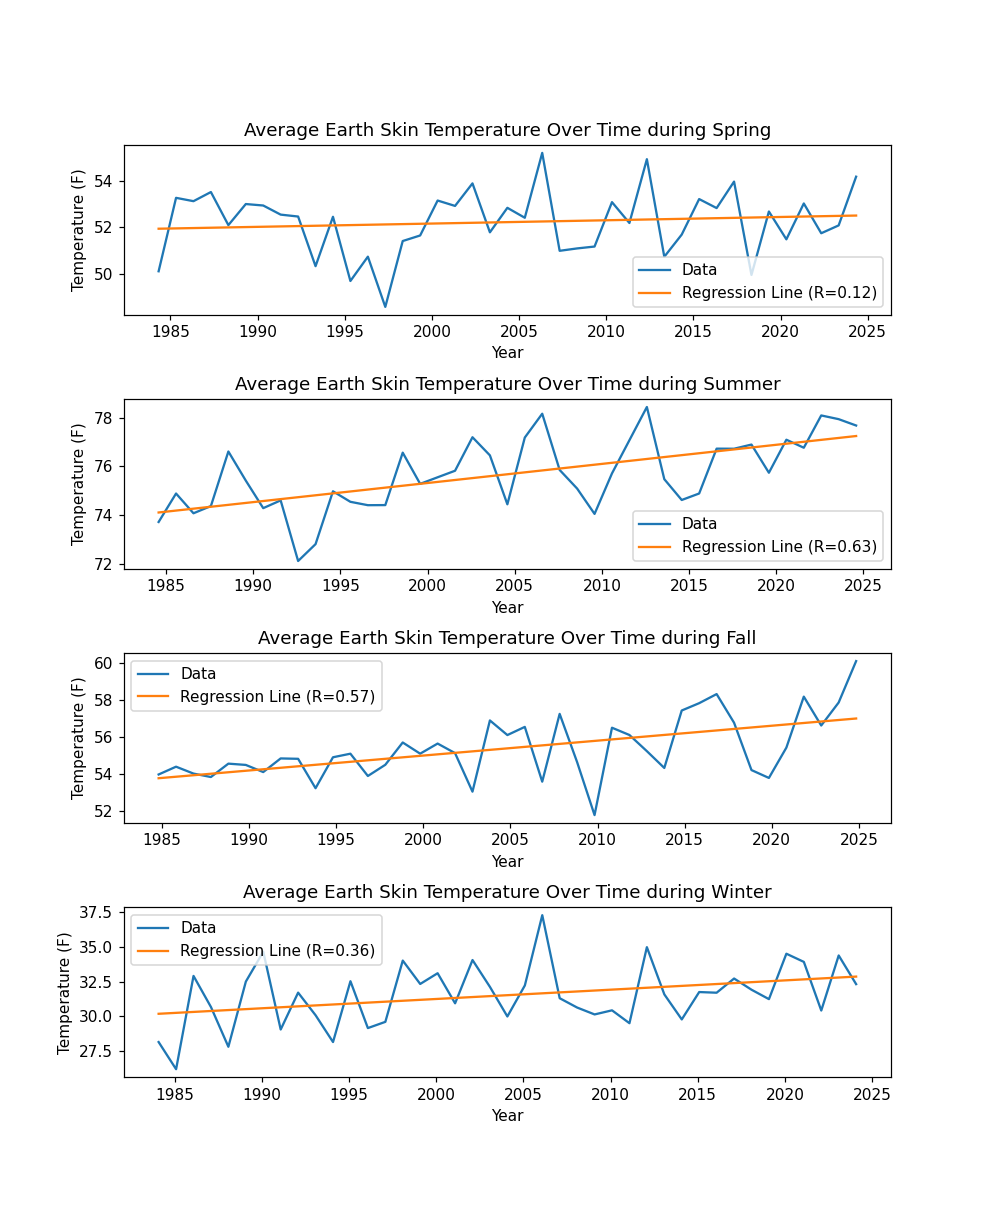


Spring: 
Slope: 3.879994899868194e-05
Intercept: 51.936135349841614
Correlation Coefficient (R): 0.12069569719039328
R-squared: 0.014567451320275107

Summer: 
Slope: 0.000215196701350561
Intercept: 74.09816804292733
Correlation Coefficient (R): 0.6311159492370261
R-squared: 0.3983073413813525

Fall: 
Slope: 0.0002206456721794399
Intercept: 53.76379353021325
Correlation Coefficient (R): 0.5715228545725993
R-squared: 0.3266383732988125

Winter: 
Slope: 0.00018328894083924162
Intercept: 30.192374370008842
Correlation Coefficient (R): 0.3596679288444951
R-squared: 0.1293610190392888


In [9]:
'''

A correlation of +0.8 indicates a strong positive linear relationship. 
A correlation of -0.6 indicates a moderate negative linear relationship. 
A correlation of 0.2 indicates a weak positive linear relationship. 

'''

fig, axs = plt.subplots(4, 1,figsize=(9, 11))

df_temp_plot = df[['time','earth_skin_temp']]
df_temp_plot = df_temp_plot.groupby(['time']).mean()

df_temp_plot.index = df_temp_plot.index.astype('datetime64[ns]')

df_temp_winter = df_temp_plot[df_temp_plot.index.month == 1] # seasonal bins
df_temp_spring = df_temp_plot[df_temp_plot.index.month == 4]
df_temp_summer = df_temp_plot[df_temp_plot.index.month == 7]
df_temp_fall = df_temp_plot[df_temp_plot.index.month == 10]

axs[0].set_xlabel("Year")
axs[0].set_ylabel("Temperature (F)")
axs[0].set_title("Average Earth Skin Temperature Over Time during Spring") 

axs[1].set_xlabel("Year")
axs[1].set_ylabel("Temperature (F)")
axs[1].set_title("Average Earth Skin Temperature Over Time during Summer")

axs[2].set_xlabel("Year")
axs[2].set_ylabel("Temperature (F)")
axs[2].set_title("Average Earth Skin Temperature Over Time during Fall")

axs[3].set_xlabel("Year")
axs[3].set_ylabel("Temperature (F)")
axs[3].set_title("Average Earth Skin Temperature Over Time during Winter")

#spring
dates = df_temp_spring.index .to_numpy()
values = df_temp_spring['earth_skin_temp'].to_numpy()

df_average_TS = pd.DataFrame({'date': dates, 'value': values})
df_average_TS['date_num'] = (df_average_TS['date'] - df_average_TS['date'].min()).dt.days

reg_result = linregress(df_average_TS['date_num'], df_average_TS['value'])


slope = reg_result.slope
intercept = reg_result.intercept
r_value = reg_result.rvalue  # This is the correlation coefficient

print(f"\nSpring: ")
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"Correlation Coefficient (R): {r_value}")
print(f"R-squared: {r_value**2}")

regression_line = slope * df_average_TS['date_num'] + intercept
axs[0].plot(df_average_TS['date'].to_numpy(), df_temp_spring['earth_skin_temp'].to_numpy(),'-', label='Data')
axs[0].plot(df_average_TS['date'].to_numpy(), regression_line.to_numpy(), label=f'Regression Line (R={r_value:.2f})') 


           
#summer
dates = df_temp_summer.index .to_numpy()
values = df_temp_summer['earth_skin_temp'].to_numpy()

df_average_TS = pd.DataFrame({'date': dates, 'value': values})
df_average_TS['date_num'] = (df_average_TS['date'] - df_average_TS['date'].min()).dt.days
reg_result = linregress(df_average_TS['date_num'], df_average_TS['value'])


slope = reg_result.slope
intercept = reg_result.intercept
r_value = reg_result.rvalue  # This is the correlation coefficient


regression_line = slope * df_average_TS['date_num'] + intercept
print(f"\nSummer: ")
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"Correlation Coefficient (R): {r_value}")
print(f"R-squared: {r_value**2}")
axs[1].plot(df_average_TS['date'].to_numpy(), df_temp_summer['earth_skin_temp'].to_numpy(),'-', label='Data')
axs[1].plot(df_average_TS['date'].to_numpy(), regression_line.to_numpy(), label=f'Regression Line (R={r_value:.2f})')  


#fall
dates = df_temp_fall.index .to_numpy()
values = df_temp_fall['earth_skin_temp'].to_numpy()

df_average_TS = pd.DataFrame({'date': dates, 'value': values})
df_average_TS['date_num'] = (df_average_TS['date'] - df_average_TS['date'].min()).dt.days
reg_result = linregress(df_average_TS['date_num'], df_average_TS['value'])


slope = reg_result.slope
intercept = reg_result.intercept
r_value = reg_result.rvalue  # This is the correlation coefficient
regression_line = slope * df_average_TS['date_num'] + intercept
print(f"\nFall: ")
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"Correlation Coefficient (R): {r_value}")
print(f"R-squared: {r_value**2}")
axs[2].plot(df_average_TS['date'].to_numpy(), df_temp_fall['earth_skin_temp'].to_numpy(),'-', label='Data')
axs[2].plot(df_average_TS['date'].to_numpy(), regression_line.to_numpy(), label=f'Regression Line (R={r_value:.2f})')    
    
    
#winter
dates = df_temp_winter.index .to_numpy()
values = df_temp_winter['earth_skin_temp'].to_numpy()

df_average_TS = pd.DataFrame({'date': dates, 'value': values})
df_average_TS['date_num'] = (df_average_TS['date'] - df_average_TS['date'].min()).dt.days
reg_result = linregress(df_average_TS['date_num'], df_average_TS['value'])


slope = reg_result.slope
intercept = reg_result.intercept
r_value = reg_result.rvalue  # This is the correlation coefficient
regression_line = slope * df_average_TS['date_num'] + intercept
print(f"\nWinter: ")
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"Correlation Coefficient (R): {r_value}")
print(f"R-squared: {r_value**2}")
axs[3].plot(df_average_TS['date'].to_numpy(), df_temp_winter['earth_skin_temp'].to_numpy(),'-', label='Data')
axs[3].plot(df_average_TS['date'].to_numpy(), regression_line.to_numpy(), label=f'Regression Line (R={r_value:.2f})')   


plt.subplots_adjust(wspace=0.4, hspace=0.5)
axs[0].legend()
axs[1].legend()
axs[2].legend()
axs[3].legend()
plt.show()


The trend of LST over the last 40 years show a moderate positive correlation over time during the summer and fall while showing a weak positive correlation during the winter. During the spring, the correlation coefficient of the regression model is not strong enough to explain any trend in LST.

# 




# What is "Precipitation"?

In this context, preciptation will be defined as the total amount of rainfall measured by depth in millimeters. The amount of precipitation may affect climate trends as the rainwater transfers or absorbs heat from the surrounding environment, which may alter expected climate trends. Areas with more precipitation than usual may experience variation in climate.

<IPython.core.display.Javascript object>


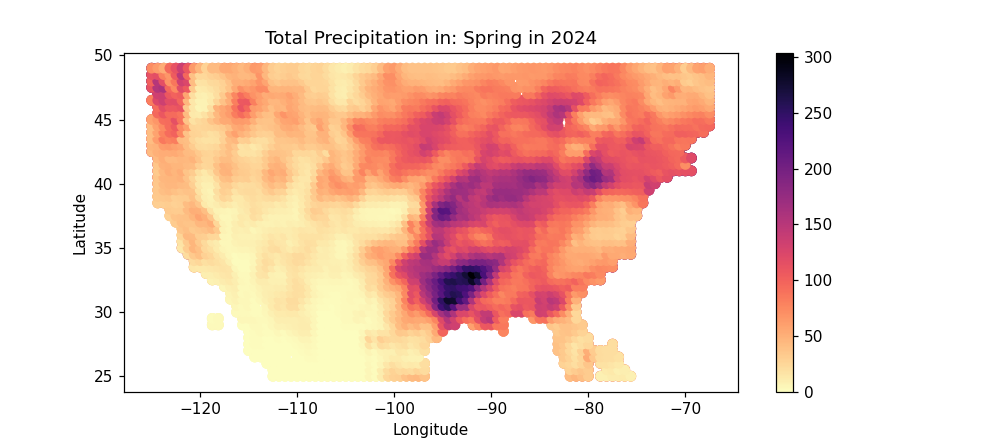

interactive(children=(IntSlider(value=1, description='Season:', max=4, min=1), IntSlider(value=1984, descripti…

In [10]:

#allows interactive widgets
%matplotlib nbagg

df_winter=df[df['time'] == '2020-01-31'] # for all 4 seasons
df_spring=df[df['time'] == '2020-04-30']
df_summer=df[df['time'] == '2020-07-31']
df_fall=df[df['time'] == '2020-10-31']

fig = plt.figure(figsize=(9, 4))

plt.title('Total Precipitation in: ', horizontalalignment = 'center')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

#constant
x = df_spring['long']
y = df_spring['lat']

season_name = ['Spring','Summer','Fall','Winter']

year_array = []#3D array for caching
year_difference = end_date.year - start_date.year

cbar = plt.colorbar(plt.scatter(x, y,  c = [], cmap='magma_r'))

for i in range(year_difference+1):
    df_winter=df[df['time'] == str(start_date.year+i)+'-01-31'] 
    df_spring=df[df['time'] == str(start_date.year+i)+'-04-30']
    df_summer=df[df['time'] == str(start_date.year+i)+'-07-31']
    df_fall=df[df['time'] == str(start_date.year+i)+'-10-31']
    
    sp = df_spring['precipitation']
    sm = df_summer['precipitation']
    f = df_fall['precipitation']
    w = df_winter['precipitation']
    
    year_array.append([sp,sm,f,w])

def update_plot(season,year):
    global cbar, season_name,data
    
    plt.title('Total Precipitation in: '+ season_name[season-1] + " in " + str(year), horizontalalignment = 'center')
    
    season_data = year_array[year-start_date.year][season-1]
    
    scatter_plot = plt.scatter(x, y,  c = season_data, cmap='magma_r')

    cbar.remove()
    cbar = plt.colorbar(scatter_plot)
    
    plt.show()
    
season = widgets.IntSlider(min=1, max=4, value=1, description='Season:')
year = widgets.IntSlider(min=start_date.year, max=end_date.year, value=1, description='Year:') 

widgets.interactive(update_plot, season = season, year= year)


<IPython.core.display.Javascript object>


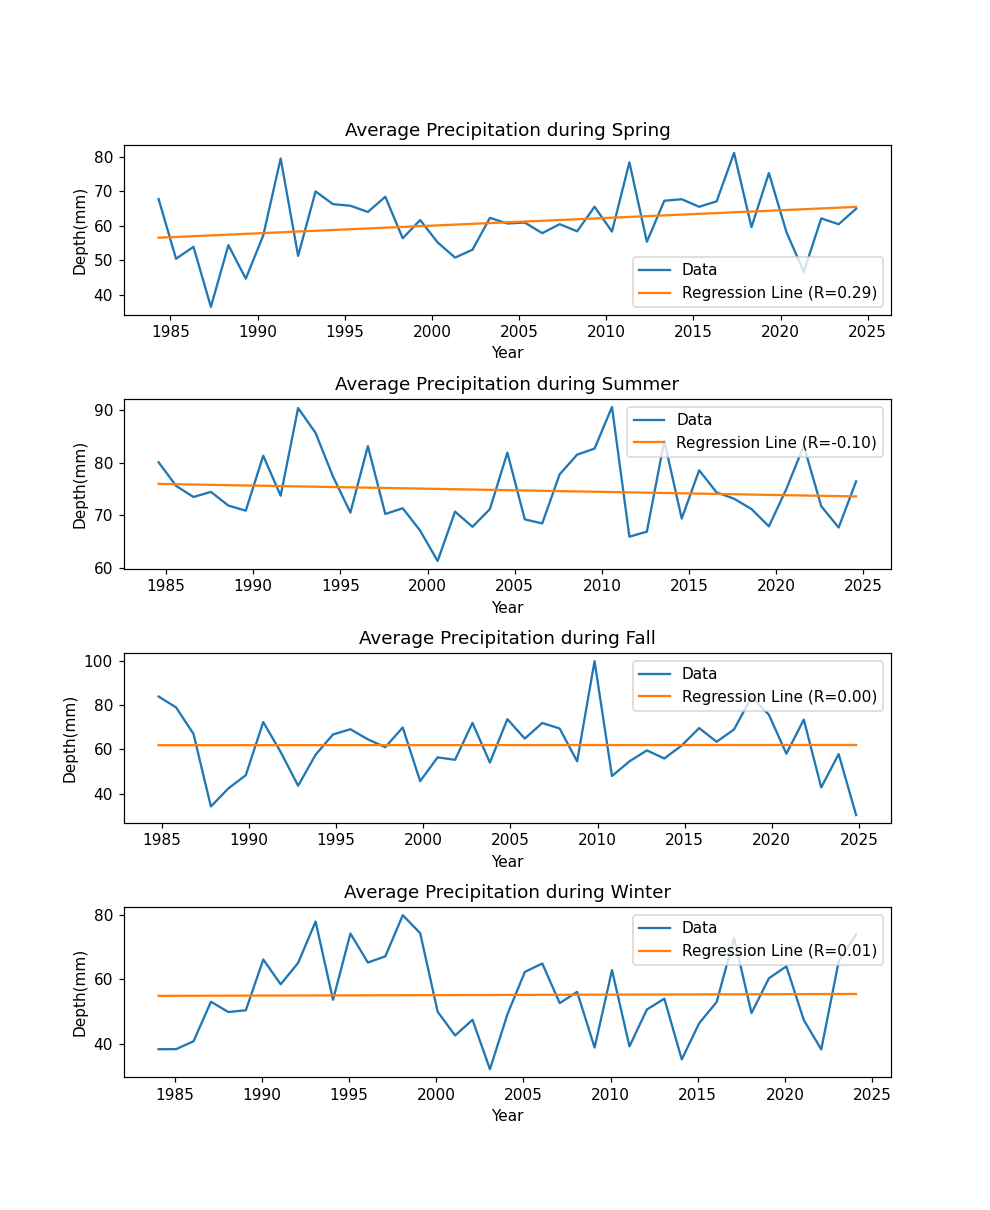


Spring: 
Slope: 0.0006109613378831677
Intercept: 56.59535779664938
Correlation Coefficient (R): 0.2920558241360625
R-squared: 0.08529660441179468

Summer: 
Slope: -0.00016271883162473957
Intercept: 75.97083998401718
Correlation Coefficient (R): -0.10465749713023774
R-squared: 0.010953191705565721

Fall: 
Slope: 6.4449558651780925e-06
Intercept: 61.91496773188051
Correlation Coefficient (R): 0.002039432354472773
R-squared: 4.159284328470358e-06

Winter: 
Slope: 4.049553977671953e-05
Intercept: 54.86343298846178
Correlation Coefficient (R): 0.013936319231916173
R-squared: 0.0001942209937338766


In [11]:
'''

A correlation of +0.8 indicates a strong positive linear relationship. 
A correlation of -0.6 indicates a moderate negative linear relationship. 
A correlation of 0.2 indicates a weak positive linear relationship. 

'''

fig, axs = plt.subplots(4, 1,figsize=(9, 11))

df_temp_plot = df[['time','precipitation']]
df_temp_plot = df_temp_plot.groupby(['time']).mean()

df_temp_plot.index = df_temp_plot.index.astype('datetime64[ns]')

df_temp_winter = df_temp_plot[df_temp_plot.index.month == 1] # seasonal bins
df_temp_spring = df_temp_plot[df_temp_plot.index.month == 4]
df_temp_summer = df_temp_plot[df_temp_plot.index.month == 7]
df_temp_fall = df_temp_plot[df_temp_plot.index.month == 10]

axs[0].set_xlabel("Year")
axs[0].set_ylabel("Depth(mm)")
axs[0].set_title("Average Precipitation during Spring") 

axs[1].set_xlabel("Year")
axs[1].set_ylabel("Depth(mm)")
axs[1].set_title("Average Precipitation during Summer")

axs[2].set_xlabel("Year")
axs[2].set_ylabel("Depth(mm)")
axs[2].set_title("Average Precipitation during Fall")

axs[3].set_xlabel("Year")
axs[3].set_ylabel("Depth(mm)")
axs[3].set_title("Average Precipitation during Winter")

#spring
dates = df_temp_spring.index .to_numpy()
values = df_temp_spring['precipitation'].to_numpy()

df_average_TS = pd.DataFrame({'date': dates, 'value': values})
df_average_TS['date_num'] = (df_average_TS['date'] - df_average_TS['date'].min()).dt.days

reg_result = linregress(df_average_TS['date_num'], df_average_TS['value'])


slope = reg_result.slope
intercept = reg_result.intercept
r_value = reg_result.rvalue  # This is the correlation coefficient

print(f"\nSpring: ")
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"Correlation Coefficient (R): {r_value}")
print(f"R-squared: {r_value**2}")

regression_line = slope * df_average_TS['date_num'] + intercept
axs[0].plot(df_average_TS['date'].to_numpy(), df_temp_spring['precipitation'].to_numpy(),'-', label='Data')
axs[0].plot(df_average_TS['date'].to_numpy(), regression_line.to_numpy(), label=f'Regression Line (R={r_value:.2f})') 


           
#summer
dates = df_temp_summer.index .to_numpy()
values = df_temp_summer['precipitation'].to_numpy()

df_average_TS = pd.DataFrame({'date': dates, 'value': values})
df_average_TS['date_num'] = (df_average_TS['date'] - df_average_TS['date'].min()).dt.days
reg_result = linregress(df_average_TS['date_num'], df_average_TS['value'])


slope = reg_result.slope
intercept = reg_result.intercept
r_value = reg_result.rvalue  # This is the correlation coefficient


regression_line = slope * df_average_TS['date_num'] + intercept
print(f"\nSummer: ")
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"Correlation Coefficient (R): {r_value}")
print(f"R-squared: {r_value**2}")
axs[1].plot(df_average_TS['date'].to_numpy(), df_temp_summer['precipitation'].to_numpy(),'-', label='Data')
axs[1].plot(df_average_TS['date'].to_numpy(), regression_line.to_numpy(), label=f'Regression Line (R={r_value:.2f})')  


#fall
dates = df_temp_fall.index .to_numpy()
values = df_temp_fall['precipitation'].to_numpy()

df_average_TS = pd.DataFrame({'date': dates, 'value': values})
df_average_TS['date_num'] = (df_average_TS['date'] - df_average_TS['date'].min()).dt.days
reg_result = linregress(df_average_TS['date_num'], df_average_TS['value'])


slope = reg_result.slope
intercept = reg_result.intercept
r_value = reg_result.rvalue  # This is the correlation coefficient
regression_line = slope * df_average_TS['date_num'] + intercept
print(f"\nFall: ")
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"Correlation Coefficient (R): {r_value}")
print(f"R-squared: {r_value**2}")
axs[2].plot(df_average_TS['date'].to_numpy(), df_temp_fall['precipitation'].to_numpy(),'-', label='Data')
axs[2].plot(df_average_TS['date'].to_numpy(), regression_line.to_numpy(), label=f'Regression Line (R={r_value:.2f})')    
    
    
#winter
dates = df_temp_winter.index .to_numpy()
values = df_temp_winter['precipitation'].to_numpy()

df_average_TS = pd.DataFrame({'date': dates, 'value': values})
df_average_TS['date_num'] = (df_average_TS['date'] - df_average_TS['date'].min()).dt.days
reg_result = linregress(df_average_TS['date_num'], df_average_TS['value'])


slope = reg_result.slope
intercept = reg_result.intercept
r_value = reg_result.rvalue  # This is the correlation coefficient
regression_line = slope * df_average_TS['date_num'] + intercept
print(f"\nWinter: ")
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"Correlation Coefficient (R): {r_value}")
print(f"R-squared: {r_value**2}")
axs[3].plot(df_average_TS['date'].to_numpy(), df_temp_winter['precipitation'].to_numpy(),'-', label='Data')
axs[3].plot(df_average_TS['date'].to_numpy(), regression_line.to_numpy(), label=f'Regression Line (R={r_value:.2f})')   


plt.subplots_adjust(wspace=0.4, hspace=0.5)
axs[0].legend()
axs[1].legend()
axs[2].legend()
axs[3].legend()
plt.show()


During the spring the regression model shows a weak positive correlation in precipitation. The regression model's correlation coeffiecent is not strong enough to explain any trend in precipation over the years for the seasons of summer, fall, and winter.

# 




# What is "Total Column Precipitable Water"?

Total column precipitable water or TCPW, is defined as the measure of the total amount of water vapor in a vertical column of air, from the surface to the top of the atmosphere. Water vapor is known to retain heat better than normal air as well as influence the amount of precipitation in that area. These effects may contribute to a rise in overall climate trends.

<IPython.core.display.Javascript object>


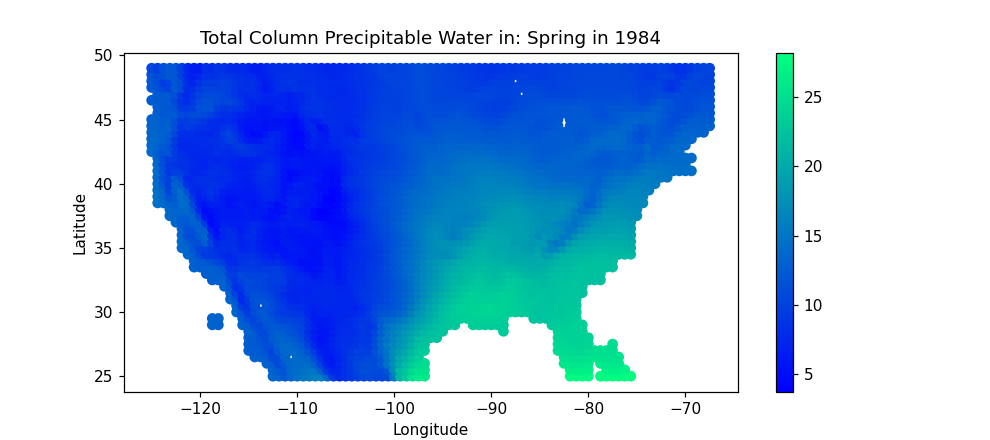

interactive(children=(IntSlider(value=1, description='Season:', max=4, min=1), IntSlider(value=1984, descripti…

In [12]:


#allows interactive widgets
%matplotlib nbagg

df_winter=df[df['time'] == '2020-01-31'] # for all 4 seasons
df_spring=df[df['time'] == '2020-04-30']
df_summer=df[df['time'] == '2020-07-31']
df_fall=df[df['time'] == '2020-10-31']

fig = plt.figure(figsize=(9, 4))

plt.title('Total Column Precipitable Water in:', horizontalalignment = 'center')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

#constant
x = df_spring['long']
y = df_spring['lat']

season_name = ['Spring','Summer','Fall','Winter']

year_array = []#3D array for caching
year_difference = end_date.year - start_date.year

cbar = plt.colorbar(plt.scatter(x, y,  c = [], cmap='plasma'))

for i in range(year_difference+1):
    df_winter=df[df['time'] == str(start_date.year+i)+'-01-31'] 
    df_spring=df[df['time'] == str(start_date.year+i)+'-04-30']
    df_summer=df[df['time'] == str(start_date.year+i)+'-07-31']
    df_fall=df[df['time'] == str(start_date.year+i)+'-10-31']
    
    sp = df_spring['total_column_precipitable_water']
    sm = df_summer['total_column_precipitable_water']
    f = df_fall['total_column_precipitable_water']
    w = df_winter['total_column_precipitable_water']
    
    year_array.append([sp,sm,f,w])

def update_plot(season,year):
    global cbar, season_name,data
    
    plt.title('Total Column Precipitable Water in: '+ season_name[season-1] + " in " + str(year), horizontalalignment = 'center')
    
    season_data = year_array[year-start_date.year][season-1]
    
    scatter_plot = plt.scatter(x, y,  c = season_data, cmap='winter')

    cbar.remove()
    cbar = plt.colorbar(scatter_plot)
    
    plt.show()
    
season = widgets.IntSlider(min=1, max=4, value=1, description='Season:')
year = widgets.IntSlider(min=start_date.year, max=end_date.year, value=1, description='Year:') 

widgets.interactive(update_plot, season = season, year= year)



<IPython.core.display.Javascript object>


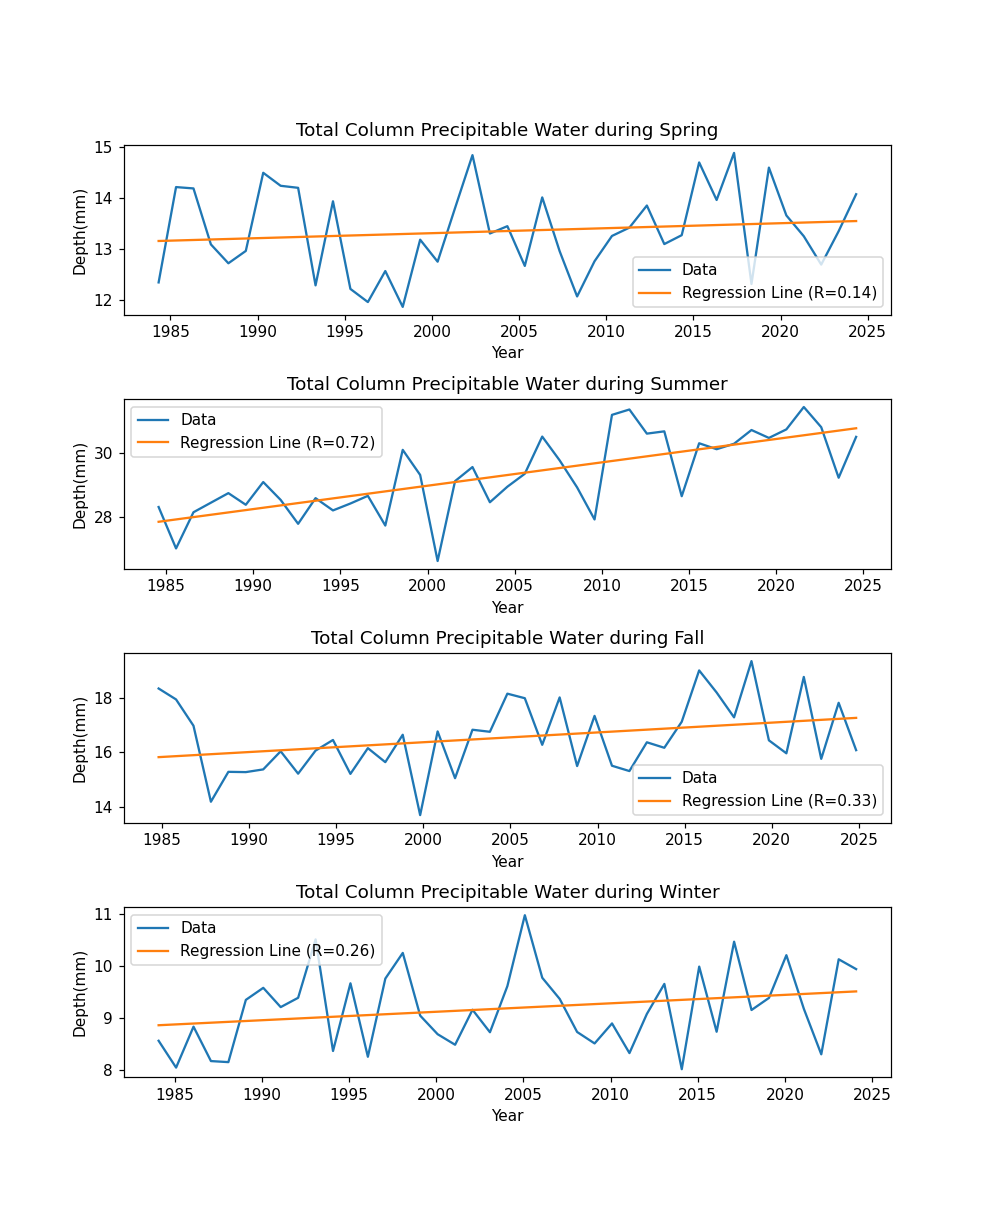


Spring: 
Slope: 2.677632427521708e-05
Intercept: 13.153264752980698
Correlation Coefficient (R): 0.14027046209872795
R-squared: 0.019675802537390676

Summer: 
Slope: 0.00020023502984434935
Intercept: 27.85774271615604
Correlation Coefficient (R): 0.7246833594645855
R-squared: 0.5251659714848776

Fall: 
Slope: 9.796587848139066e-05
Intercept: 15.826826226663558
Correlation Coefficient (R): 0.33165332656363294
R-squared: 0.10999392902072376

Winter: 
Slope: 4.462413031259864e-05
Intercept: 8.855854760658163
Correlation Coefficient (R): 0.25820070688923447
R-squared: 0.06666760503810037


In [13]:
'''

A correlation of +0.8 indicates a strong positive linear relationship. 
A correlation of -0.6 indicates a moderate negative linear relationship. 
A correlation of 0.2 indicates a weak positive linear relationship. 

'''

fig, axs = plt.subplots(4, 1,figsize=(9, 11))

df_temp_plot = df[['time','total_column_precipitable_water']]# humidity
df_temp_plot = df_temp_plot.groupby(['time']).mean()

df_temp_plot.index = df_temp_plot.index.astype('datetime64[ns]')

df_temp_winter = df_temp_plot[df_temp_plot.index.month == 1] # seasonal bins
df_temp_spring = df_temp_plot[df_temp_plot.index.month == 4]
df_temp_summer = df_temp_plot[df_temp_plot.index.month == 7]
df_temp_fall = df_temp_plot[df_temp_plot.index.month == 10]

axs[0].set_xlabel("Year")
axs[0].set_ylabel("Depth(mm)")
axs[0].set_title("Total Column Precipitable Water during Spring") 

axs[1].set_xlabel("Year")
axs[1].set_ylabel("Depth(mm)")
axs[1].set_title("Total Column Precipitable Water during Summer")

axs[2].set_xlabel("Year")
axs[2].set_ylabel("Depth(mm)")
axs[2].set_title("Total Column Precipitable Water during Fall")

axs[3].set_xlabel("Year")
axs[3].set_ylabel("Depth(mm)")
axs[3].set_title("Total Column Precipitable Water during Winter")

#spring
dates = df_temp_spring.index .to_numpy()
values = df_temp_spring['total_column_precipitable_water'].to_numpy()

df_average_TS = pd.DataFrame({'date': dates, 'value': values})
df_average_TS['date_num'] = (df_average_TS['date'] - df_average_TS['date'].min()).dt.days

reg_result = linregress(df_average_TS['date_num'], df_average_TS['value'])


slope = reg_result.slope
intercept = reg_result.intercept
r_value = reg_result.rvalue  # This is the correlation coefficient

print(f"\nSpring: ")
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"Correlation Coefficient (R): {r_value}")
print(f"R-squared: {r_value**2}")

regression_line = slope * df_average_TS['date_num'] + intercept
axs[0].plot(df_average_TS['date'].to_numpy(), df_temp_spring['total_column_precipitable_water'].to_numpy(),'-', label='Data')
axs[0].plot(df_average_TS['date'].to_numpy(), regression_line.to_numpy(), label=f'Regression Line (R={r_value:.2f})') 


           
#summer
dates = df_temp_summer.index .to_numpy()
values = df_temp_summer['total_column_precipitable_water'].to_numpy()

df_average_TS = pd.DataFrame({'date': dates, 'value': values})
df_average_TS['date_num'] = (df_average_TS['date'] - df_average_TS['date'].min()).dt.days
reg_result = linregress(df_average_TS['date_num'], df_average_TS['value'])


slope = reg_result.slope
intercept = reg_result.intercept
r_value = reg_result.rvalue  # This is the correlation coefficient


regression_line = slope * df_average_TS['date_num'] + intercept
print(f"\nSummer: ")
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"Correlation Coefficient (R): {r_value}")
print(f"R-squared: {r_value**2}")
axs[1].plot(df_average_TS['date'].to_numpy(), df_temp_summer['total_column_precipitable_water'].to_numpy(),'-', label='Data')
axs[1].plot(df_average_TS['date'].to_numpy(), regression_line.to_numpy(), label=f'Regression Line (R={r_value:.2f})')  


#fall
dates = df_temp_fall.index .to_numpy()
values = df_temp_fall['total_column_precipitable_water'].to_numpy()

df_average_TS = pd.DataFrame({'date': dates, 'value': values})
df_average_TS['date_num'] = (df_average_TS['date'] - df_average_TS['date'].min()).dt.days
reg_result = linregress(df_average_TS['date_num'], df_average_TS['value'])


slope = reg_result.slope
intercept = reg_result.intercept
r_value = reg_result.rvalue  # This is the correlation coefficient
regression_line = slope * df_average_TS['date_num'] + intercept
print(f"\nFall: ")
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"Correlation Coefficient (R): {r_value}")
print(f"R-squared: {r_value**2}")
axs[2].plot(df_average_TS['date'].to_numpy(), df_temp_fall['total_column_precipitable_water'].to_numpy(),'-', label='Data')
axs[2].plot(df_average_TS['date'].to_numpy(), regression_line.to_numpy(), label=f'Regression Line (R={r_value:.2f})')    
    
    
#winter
dates = df_temp_winter.index .to_numpy()
values = df_temp_winter['total_column_precipitable_water'].to_numpy()

df_average_TS = pd.DataFrame({'date': dates, 'value': values})
df_average_TS['date_num'] = (df_average_TS['date'] - df_average_TS['date'].min()).dt.days
reg_result = linregress(df_average_TS['date_num'], df_average_TS['value'])


slope = reg_result.slope
intercept = reg_result.intercept
r_value = reg_result.rvalue  # This is the correlation coefficient
regression_line = slope * df_average_TS['date_num'] + intercept
print(f"\nWinter: ")
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"Correlation Coefficient (R): {r_value}")
print(f"R-squared: {r_value**2}")
axs[3].plot(df_average_TS['date'].to_numpy(), df_temp_winter['total_column_precipitable_water'].to_numpy(),'-', label='Data')
axs[3].plot(df_average_TS['date'].to_numpy(), regression_line.to_numpy(), label=f'Regression Line (R={r_value:.2f})')   


plt.subplots_adjust(wspace=0.4, hspace=0.5)
axs[0].legend()
axs[1].legend()
axs[2].legend()
axs[3].legend()
plt.show()


The regression model shows a moderate positve correlation of TCPW during the summer. The regression model shows a weak positve correlation of TCPW during the fall and winter seasons. The correlation coefficent is not strong enough to explain any trend in TCPW for the spring.

# 




# What is "Profile Soil Moisture"?

Profile soil moisture or PSM, is defined as the measurement of water content from bedrock to the surface or in simpler terms how much water is saturating the soil. In this context PSM is measured as a percentage of saturation from 0 to 1. Higher PSM may lead to effects other than just an variance in temperature, as more water content in the soil may change precipitation drainage as well as other factors like vegetation and overall ecosystem health.

<IPython.core.display.Javascript object>


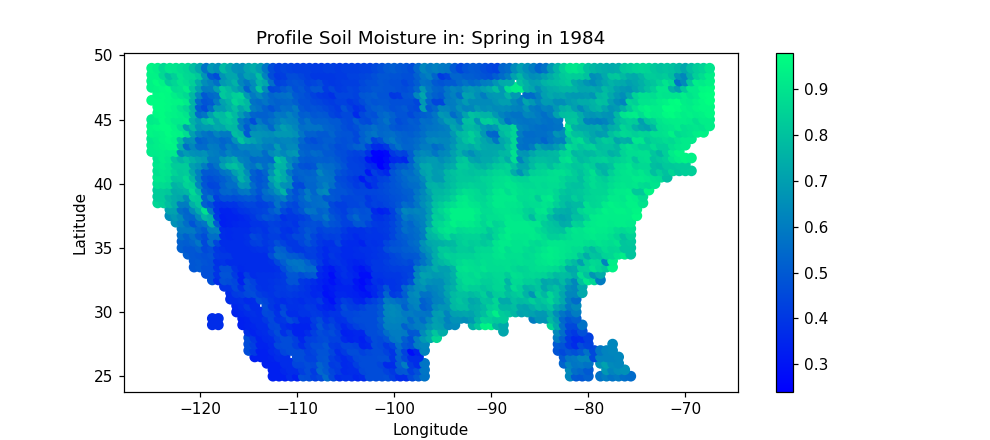

interactive(children=(IntSlider(value=1, description='Season:', max=4, min=1), IntSlider(value=1984, descripti…

In [14]:


#allows interactive widgets
%matplotlib nbagg

df_winter=df[df['time'] == '2020-01-31'] # for all 4 seasons
df_spring=df[df['time'] == '2020-04-30']
df_summer=df[df['time'] == '2020-07-31']
df_fall=df[df['time'] == '2020-10-31']

fig = plt.figure(figsize=(9, 4))

plt.title('profile_soil_moisture in: ', horizontalalignment = 'center')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

#constant
x = df_spring['long']
y = df_spring['lat']

season_name = ['Spring','Summer','Fall','Winter']

year_array = []#3D array for caching
year_difference = end_date.year - start_date.year

cbar = plt.colorbar(plt.scatter(x, y,  c = [], cmap='winter'))

for i in range(year_difference+1):
    df_winter=df[df['time'] == str(start_date.year+i)+'-01-31'] 
    df_spring=df[df['time'] == str(start_date.year+i)+'-04-30']
    df_summer=df[df['time'] == str(start_date.year+i)+'-07-31']
    df_fall=df[df['time'] == str(start_date.year+i)+'-10-31']
    
    sp = df_spring['profile_soil_moisture']
    sm = df_summer['profile_soil_moisture']
    f = df_fall['profile_soil_moisture']
    w = df_winter['profile_soil_moisture']
    
    year_array.append([sp,sm,f,w])

def update_plot(season,year):
    global cbar, season_name,data
    
    plt.title('Profile Soil Moisture in: '+ season_name[season-1] + " in " + str(year), horizontalalignment = 'center')
    
    season_data = year_array[year-start_date.year][season-1]
    
    scatter_plot = plt.scatter(x, y,  c = season_data, cmap='winter')

    cbar.remove()
    cbar = plt.colorbar(scatter_plot)
    
    plt.show()
    
season = widgets.IntSlider(min=1, max=4, value=1, description='Season:')
year = widgets.IntSlider(min=start_date.year, max=end_date.year, value=1, description='Year:') 

widgets.interactive(update_plot, season = season, year= year)



<IPython.core.display.Javascript object>


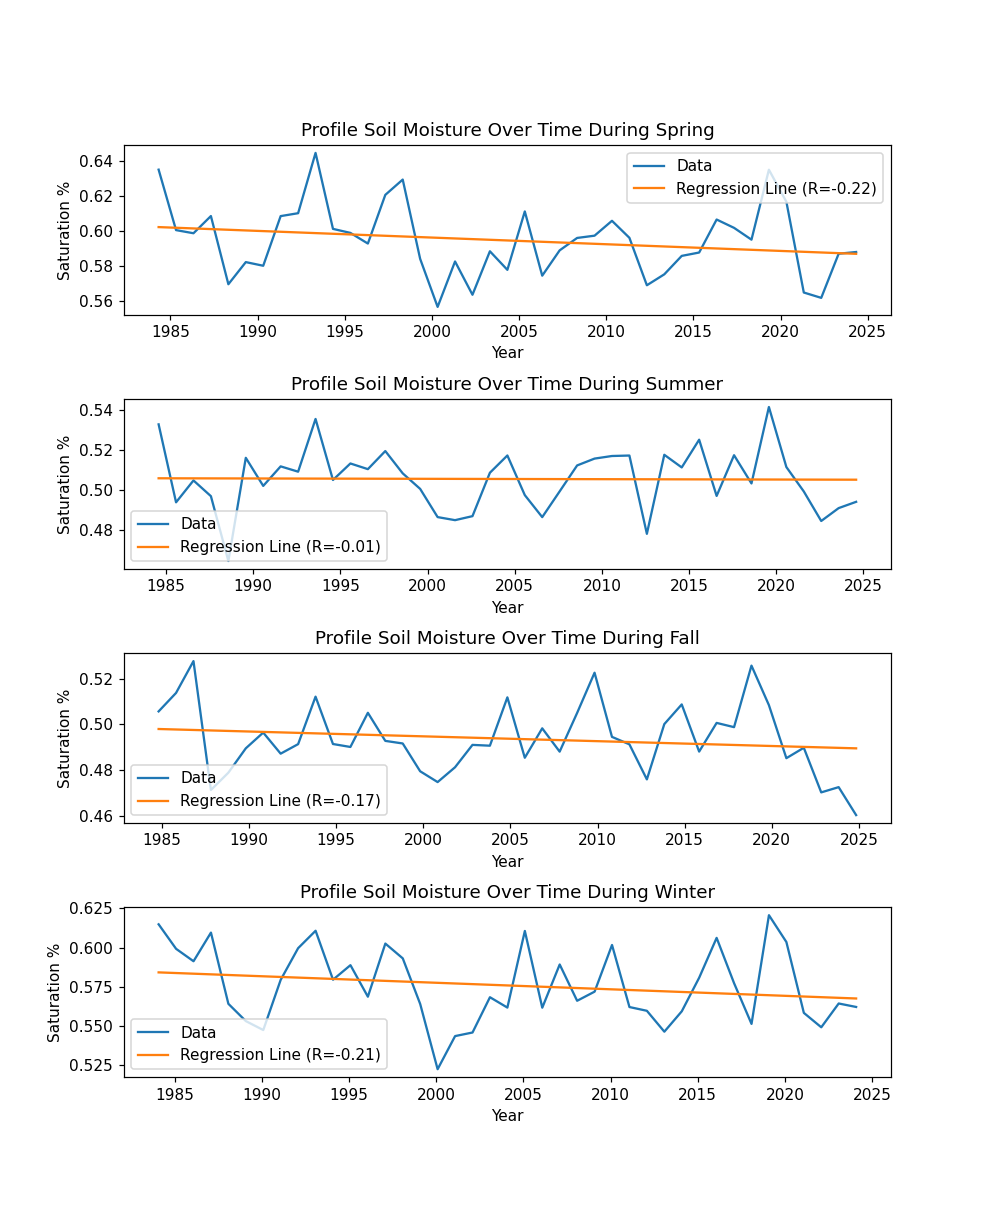


Spring: 
Slope: -1.0467300737137009e-06
Intercept: 0.6021999777180572
Correlation Coefficient (R): -0.22095049369851213
R-squared: 0.04881912066561625

Summer: 
Slope: -4.866744700811439e-08
Intercept: 0.5056743378665403
Correlation Coefficient (R): -0.013566133952795151
R-squared: 0.0001840399904251814

Fall: 
Slope: -5.80577785659424e-07
Intercept: 0.4979680483929522
Correlation Coefficient (R): -0.16643380811679573
R-squared: 0.02770021248425838

Winter: 
Slope: -1.1380124275258336e-06
Intercept: 0.5842083599102517
Correlation Coefficient (R): -0.2089798233383735
R-squared: 0.0436725665625378


In [15]:
'''

A correlation of +0.8 indicates a strong positive linear relationship. 
A correlation of -0.6 indicates a moderate negative linear relationship. 
A correlation of 0.2 indicates a weak positive linear relationship. 

'''

fig, axs = plt.subplots(4, 1,figsize=(9, 11))

df_temp_plot = df[['time','profile_soil_moisture']]# humidity
df_temp_plot = df_temp_plot.groupby(['time']).mean()

df_temp_plot.index = df_temp_plot.index.astype('datetime64[ns]')

df_temp_winter = df_temp_plot[df_temp_plot.index.month == 1] # seasonal bins
df_temp_spring = df_temp_plot[df_temp_plot.index.month == 4]
df_temp_summer = df_temp_plot[df_temp_plot.index.month == 7]
df_temp_fall = df_temp_plot[df_temp_plot.index.month == 10]

axs[0].set_xlabel("Year")
axs[0].set_ylabel("Saturation %")
axs[0].set_title("Profile Soil Moisture Over Time During Spring") 

axs[1].set_xlabel("Year")
axs[1].set_ylabel("Saturation %")
axs[1].set_title("Profile Soil Moisture Over Time During Summer")

axs[2].set_xlabel("Year")
axs[2].set_ylabel("Saturation %")
axs[2].set_title("Profile Soil Moisture Over Time During Fall")

axs[3].set_xlabel("Year")
axs[3].set_ylabel("Saturation %")
axs[3].set_title("Profile Soil Moisture Over Time During Winter")

#spring
dates = df_temp_spring.index .to_numpy()
values = df_temp_spring['profile_soil_moisture'].to_numpy()

df_average_TS = pd.DataFrame({'date': dates, 'value': values})
df_average_TS['date_num'] = (df_average_TS['date'] - df_average_TS['date'].min()).dt.days

reg_result = linregress(df_average_TS['date_num'], df_average_TS['value'])


slope = reg_result.slope
intercept = reg_result.intercept
r_value = reg_result.rvalue  # This is the correlation coefficient

print(f"\nSpring: ")
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"Correlation Coefficient (R): {r_value}")
print(f"R-squared: {r_value**2}")

regression_line = slope * df_average_TS['date_num'] + intercept
axs[0].plot(df_average_TS['date'].to_numpy(), df_temp_spring['profile_soil_moisture'].to_numpy(),'-', label='Data')
axs[0].plot(df_average_TS['date'].to_numpy(), regression_line.to_numpy(), label=f'Regression Line (R={r_value:.2f})') 


           
#summer
dates = df_temp_summer.index .to_numpy()
values = df_temp_summer['profile_soil_moisture'].to_numpy()

df_average_TS = pd.DataFrame({'date': dates, 'value': values})
df_average_TS['date_num'] = (df_average_TS['date'] - df_average_TS['date'].min()).dt.days
reg_result = linregress(df_average_TS['date_num'], df_average_TS['value'])


slope = reg_result.slope
intercept = reg_result.intercept
r_value = reg_result.rvalue  # This is the correlation coefficient


regression_line = slope * df_average_TS['date_num'] + intercept
print(f"\nSummer: ")
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"Correlation Coefficient (R): {r_value}")
print(f"R-squared: {r_value**2}")
axs[1].plot(df_average_TS['date'].to_numpy(), df_temp_summer['profile_soil_moisture'].to_numpy(),'-', label='Data')
axs[1].plot(df_average_TS['date'].to_numpy(), regression_line.to_numpy(), label=f'Regression Line (R={r_value:.2f})')  


#fall
dates = df_temp_fall.index .to_numpy()
values = df_temp_fall['profile_soil_moisture'].to_numpy()

df_average_TS = pd.DataFrame({'date': dates, 'value': values})
df_average_TS['date_num'] = (df_average_TS['date'] - df_average_TS['date'].min()).dt.days
reg_result = linregress(df_average_TS['date_num'], df_average_TS['value'])


slope = reg_result.slope
intercept = reg_result.intercept
r_value = reg_result.rvalue  # This is the correlation coefficient
regression_line = slope * df_average_TS['date_num'] + intercept
print(f"\nFall: ")
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"Correlation Coefficient (R): {r_value}")
print(f"R-squared: {r_value**2}")
axs[2].plot(df_average_TS['date'].to_numpy(), df_temp_fall['profile_soil_moisture'].to_numpy(),'-', label='Data')
axs[2].plot(df_average_TS['date'].to_numpy(), regression_line.to_numpy(), label=f'Regression Line (R={r_value:.2f})')    
    
    
#winter
dates = df_temp_winter.index .to_numpy()
values = df_temp_winter['profile_soil_moisture'].to_numpy()

df_average_TS = pd.DataFrame({'date': dates, 'value': values})
df_average_TS['date_num'] = (df_average_TS['date'] - df_average_TS['date'].min()).dt.days
reg_result = linregress(df_average_TS['date_num'], df_average_TS['value'])


slope = reg_result.slope
intercept = reg_result.intercept
r_value = reg_result.rvalue  # This is the correlation coefficient
regression_line = slope * df_average_TS['date_num'] + intercept
print(f"\nWinter: ")
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"Correlation Coefficient (R): {r_value}")
print(f"R-squared: {r_value**2}")
axs[3].plot(df_average_TS['date'].to_numpy(), df_temp_winter['profile_soil_moisture'].to_numpy(),'-', label='Data')
axs[3].plot(df_average_TS['date'].to_numpy(), regression_line.to_numpy(), label=f'Regression Line (R={r_value:.2f})')   


plt.subplots_adjust(wspace=0.4, hspace=0.5)
axs[0].legend()
axs[1].legend()
axs[2].legend()
axs[3].legend()
plt.show()


The regression model explains a weak negative correlation in PSM for spring and winter. The correlation coefficient is not strong enough to explain any trend in PSM over the years for summer and fall.

# 




# What is "Temperature at 2 Meters"?

The term temperature at 2 meters or T2M is the temperature of the air mass 2 meters above the surface of the earth. This is approximately the temperature the average human experiences. This also refers to the temperature of the the airmass directly affected by the LST. The T2M also affects the variance in temperatures at higher elevations. An increase in average temperatures over time is one of the key proponents of climate change.

<IPython.core.display.Javascript object>


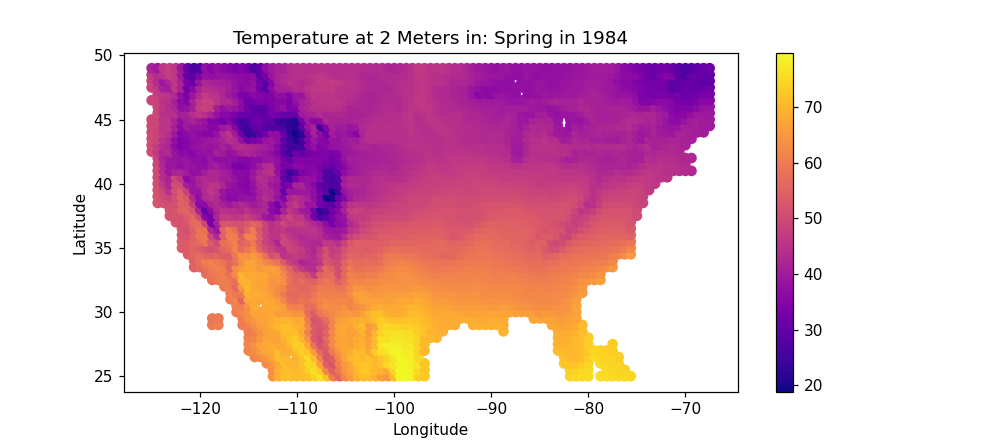

interactive(children=(IntSlider(value=1, description='Season:', max=4, min=1), IntSlider(value=1984, descripti…

In [16]:


#allows interactive widgets
%matplotlib nbagg

df_winter=df[df['time'] == '2020-01-31'] # for all 4 seasons
df_spring=df[df['time'] == '2020-04-30']
df_summer=df[df['time'] == '2020-07-31']
df_fall=df[df['time'] == '2020-10-31']

fig = plt.figure(figsize=(9, 4))

plt.title('temp_2_meter in: ', horizontalalignment = 'center')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

#constant
x = df_spring['long']
y = df_spring['lat']

season_name = ['Spring','Summer','Fall','Winter']

year_array = []#3D array for caching
year_difference = end_date.year - start_date.year

cbar = plt.colorbar(plt.scatter(x, y,  c = [], cmap='plasma'))

for i in range(year_difference+1):
    df_winter=df[df['time'] == str(start_date.year+i)+'-01-31'] 
    df_spring=df[df['time'] == str(start_date.year+i)+'-04-30']
    df_summer=df[df['time'] == str(start_date.year+i)+'-07-31']
    df_fall=df[df['time'] == str(start_date.year+i)+'-10-31']
    
    sp = df_spring['temp_2_meter']
    sm = df_summer['temp_2_meter']
    f = df_fall['temp_2_meter']
    w = df_winter['temp_2_meter']
    
    year_array.append([sp,sm,f,w])

def update_plot(season,year):
    global cbar, season_name,data
    
    plt.title('Temperature at 2 Meters in: '+ season_name[season-1] + " in " + str(year), horizontalalignment = 'center')
    
    season_data = year_array[year-start_date.year][season-1]
    
    scatter_plot = plt.scatter(x, y,  c = season_data, cmap='plasma')

    cbar.remove()
    cbar = plt.colorbar(scatter_plot)
    
    plt.show()
    
season = widgets.IntSlider(min=1, max=4, value=1, description='Season:')
year = widgets.IntSlider(min=start_date.year, max=end_date.year, value=1, description='Year:') 

widgets.interactive(update_plot, season = season, year= year)



<IPython.core.display.Javascript object>


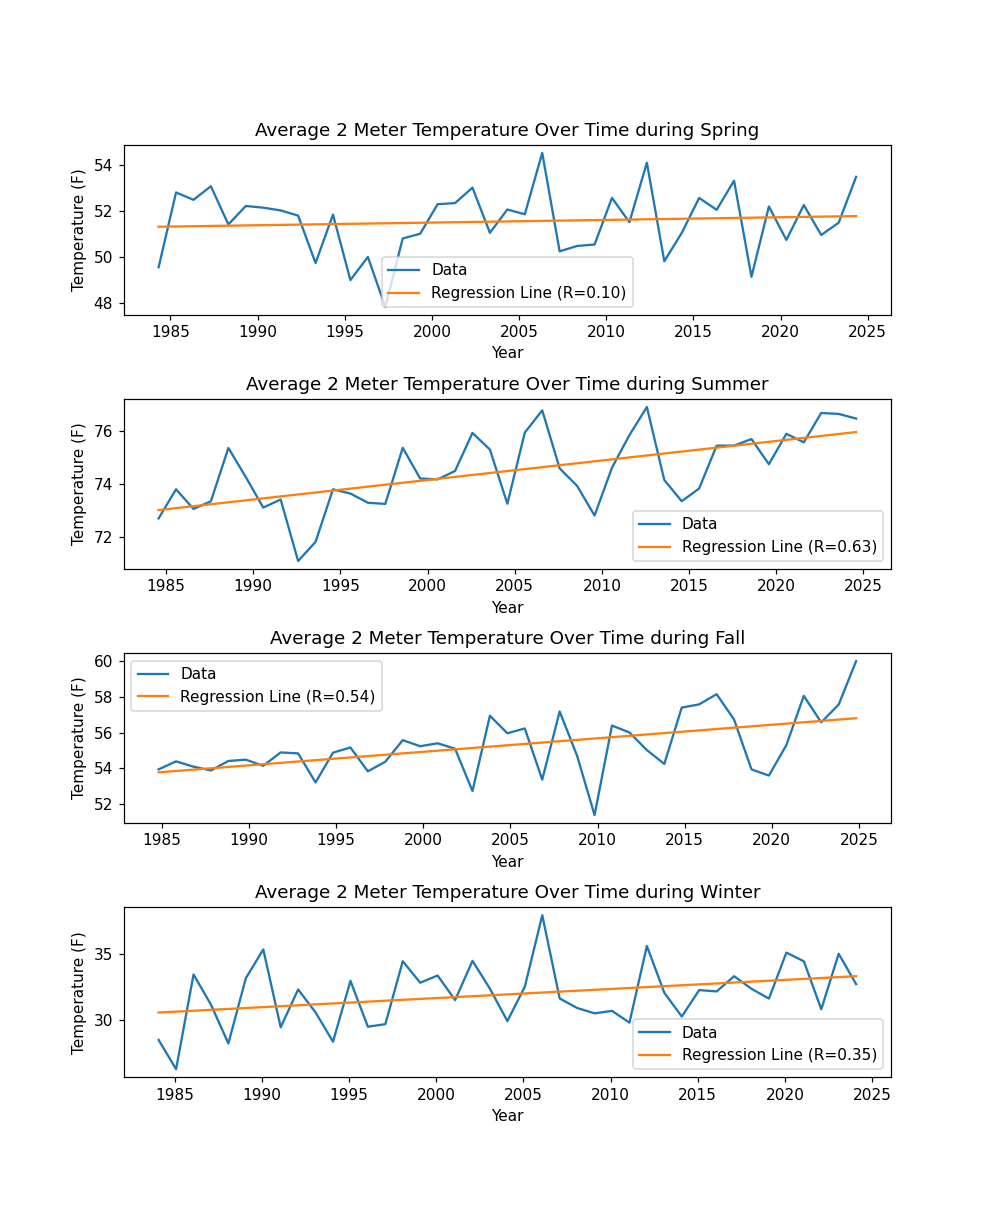


Spring: 
Slope: 3.179509885342679e-05
Intercept: 51.30807727211292
Correlation Coefficient (R): 0.09796017149725306
R-squared: 0.009596195199771231

Summer: 
Slope: 0.00020087113160960503
Intercept: 73.0182625928809
Correlation Coefficient (R): 0.6282042667790567
R-squared: 0.39464060079941227

Fall: 
Slope: 0.00020742203696468142
Intercept: 53.77913826843899
Correlation Coefficient (R): 0.5360608825647201
R-squared: 0.2873612698160666

Winter: 
Slope: 0.00018678243413916036
Intercept: 30.594300076385423
Correlation Coefficient (R): 0.3527084233086598
R-squared: 0.12440323187288076


In [17]:
'''

A correlation of +0.8 indicates a strong positive linear relationship. 
A correlation of -0.6 indicates a moderate negative linear relationship. 
A correlation of 0.2 indicates a weak positive linear relationship. 

'''

fig, axs = plt.subplots(4, 1,figsize=(9, 11))

df_temp_plot = df[['time','temp_2_meter']]# humidity
df_temp_plot = df_temp_plot.groupby(['time']).mean()

df_temp_plot.index = df_temp_plot.index.astype('datetime64[ns]')

df_temp_winter = df_temp_plot[df_temp_plot.index.month == 1] # seasonal bins
df_temp_spring = df_temp_plot[df_temp_plot.index.month == 4]
df_temp_summer = df_temp_plot[df_temp_plot.index.month == 7]
df_temp_fall = df_temp_plot[df_temp_plot.index.month == 10]

axs[0].set_xlabel("Year")
axs[0].set_ylabel("Temperature (F)")
axs[0].set_title("Average 2 Meter Temperature Over Time during Spring") 

axs[1].set_xlabel("Year")
axs[1].set_ylabel("Temperature (F)")
axs[1].set_title("Average 2 Meter Temperature Over Time during Summer")

axs[2].set_xlabel("Year")
axs[2].set_ylabel("Temperature (F)")
axs[2].set_title("Average 2 Meter Temperature Over Time during Fall")

axs[3].set_xlabel("Year")
axs[3].set_ylabel("Temperature (F)")
axs[3].set_title("Average 2 Meter Temperature Over Time during Winter")

#spring
dates = df_temp_spring.index .to_numpy()
values = df_temp_spring['temp_2_meter'].to_numpy()

df_average_TS = pd.DataFrame({'date': dates, 'value': values})
df_average_TS['date_num'] = (df_average_TS['date'] - df_average_TS['date'].min()).dt.days

reg_result = linregress(df_average_TS['date_num'], df_average_TS['value'])


slope = reg_result.slope
intercept = reg_result.intercept
r_value = reg_result.rvalue  # This is the correlation coefficient

print(f"\nSpring: ")
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"Correlation Coefficient (R): {r_value}")
print(f"R-squared: {r_value**2}")

regression_line = slope * df_average_TS['date_num'] + intercept
axs[0].plot(df_average_TS['date'].to_numpy(), df_temp_spring['temp_2_meter'].to_numpy(),'-', label='Data')
axs[0].plot(df_average_TS['date'].to_numpy(), regression_line.to_numpy(), label=f'Regression Line (R={r_value:.2f})') 


           
#summer
dates = df_temp_summer.index .to_numpy()
values = df_temp_summer['temp_2_meter'].to_numpy()

df_average_TS = pd.DataFrame({'date': dates, 'value': values})
df_average_TS['date_num'] = (df_average_TS['date'] - df_average_TS['date'].min()).dt.days
reg_result = linregress(df_average_TS['date_num'], df_average_TS['value'])


slope = reg_result.slope
intercept = reg_result.intercept
r_value = reg_result.rvalue  # This is the correlation coefficient


regression_line = slope * df_average_TS['date_num'] + intercept
print(f"\nSummer: ")
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"Correlation Coefficient (R): {r_value}")
print(f"R-squared: {r_value**2}")
axs[1].plot(df_average_TS['date'].to_numpy(), df_temp_summer['temp_2_meter'].to_numpy(),'-', label='Data')
axs[1].plot(df_average_TS['date'].to_numpy(), regression_line.to_numpy(), label=f'Regression Line (R={r_value:.2f})')  


#fall
dates = df_temp_fall.index .to_numpy()
values = df_temp_fall['temp_2_meter'].to_numpy()

df_average_TS = pd.DataFrame({'date': dates, 'value': values})
df_average_TS['date_num'] = (df_average_TS['date'] - df_average_TS['date'].min()).dt.days
reg_result = linregress(df_average_TS['date_num'], df_average_TS['value'])


slope = reg_result.slope
intercept = reg_result.intercept
r_value = reg_result.rvalue  # This is the correlation coefficient
regression_line = slope * df_average_TS['date_num'] + intercept
print(f"\nFall: ")
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"Correlation Coefficient (R): {r_value}")
print(f"R-squared: {r_value**2}")
axs[2].plot(df_average_TS['date'].to_numpy(), df_temp_fall['temp_2_meter'].to_numpy(),'-', label='Data')
axs[2].plot(df_average_TS['date'].to_numpy(), regression_line.to_numpy(), label=f'Regression Line (R={r_value:.2f})')    
    
    
#winter
dates = df_temp_winter.index .to_numpy()
values = df_temp_winter['temp_2_meter'].to_numpy()

df_average_TS = pd.DataFrame({'date': dates, 'value': values})
df_average_TS['date_num'] = (df_average_TS['date'] - df_average_TS['date'].min()).dt.days
reg_result = linregress(df_average_TS['date_num'], df_average_TS['value'])


slope = reg_result.slope
intercept = reg_result.intercept
r_value = reg_result.rvalue  # This is the correlation coefficient
regression_line = slope * df_average_TS['date_num'] + intercept
print(f"\nWinter: ")
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"Correlation Coefficient (R): {r_value}")
print(f"R-squared: {r_value**2}")
axs[3].plot(df_average_TS['date'].to_numpy(), df_temp_winter['temp_2_meter'].to_numpy(),'-', label='Data')
axs[3].plot(df_average_TS['date'].to_numpy(), regression_line.to_numpy(), label=f'Regression Line (R={r_value:.2f})')   


plt.subplots_adjust(wspace=0.4, hspace=0.5)
axs[0].legend()
axs[1].legend()
axs[2].legend()
axs[3].legend()
plt.show()


The regression model shows a moderate positive correlation of T2M over the 40 years during the seasons of summer and fall. The regression model explains a weak positive correlation of T2M during the winter. The correlation coefficient is not strong enough to explain any trend in T2M during the spring.

# 




# What is "Temperature at 10 Meters" ?

The term temperature at 10 meters or T10M is the temperature of the air mass 10 meters above the surface of the earth. This also refers to the temperature of the the airmass directly affected by the T2M. The T10M  affects the variance in temperatures at higher elevations leading change in weather phenomena as well. An increase in extreme weather activity over time is another one of the key proponents of climate change.

<IPython.core.display.Javascript object>


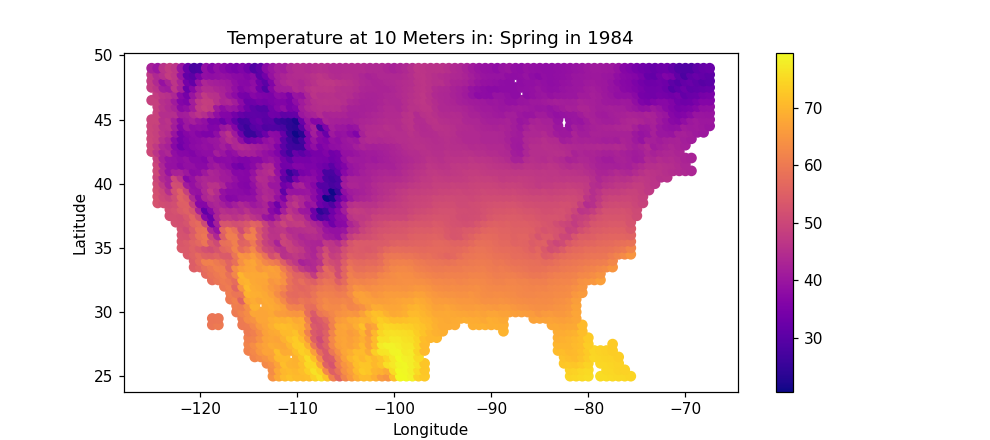

interactive(children=(IntSlider(value=1, description='Season:', max=4, min=1), IntSlider(value=1984, descripti…

In [18]:


#allows interactive widgets
%matplotlib nbagg

df_winter=df[df['time'] == '2020-01-31'] # for all 4 seasons
df_spring=df[df['time'] == '2020-04-30']
df_summer=df[df['time'] == '2020-07-31']
df_fall=df[df['time'] == '2020-10-31']

fig = plt.figure(figsize=(9, 4))

plt.title('temp_10_meter in: ', horizontalalignment = 'center')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

#constant
x = df_spring['long']
y = df_spring['lat']

season_name = ['Spring','Summer','Fall','Winter']

year_array = []#3D array for caching
year_difference = end_date.year - start_date.year

cbar = plt.colorbar(plt.scatter(x, y,  c = [], cmap='plasma'))

for i in range(year_difference+1):
    df_winter=df[df['time'] == str(start_date.year+i)+'-01-31'] 
    df_spring=df[df['time'] == str(start_date.year+i)+'-04-30']
    df_summer=df[df['time'] == str(start_date.year+i)+'-07-31']
    df_fall=df[df['time'] == str(start_date.year+i)+'-10-31']
    
    sp = df_spring['temp_10_meter']
    sm = df_summer['temp_10_meter']
    f = df_fall['temp_10_meter']
    w = df_winter['temp_10_meter']
    
    year_array.append([sp,sm,f,w])

def update_plot(season,year):
    global cbar, season_name,data
    
    plt.title('Temperature at 10 Meters in: '+ season_name[season-1] + " in " + str(year), horizontalalignment = 'center')
    
    season_data = year_array[year-start_date.year][season-1]
    
    scatter_plot = plt.scatter(x, y,  c = season_data, cmap='plasma')

    cbar.remove()
    cbar = plt.colorbar(scatter_plot)
    
    plt.show()
    
season = widgets.IntSlider(min=1, max=4, value=1, description='Season:')
year = widgets.IntSlider(min=start_date.year, max=end_date.year, value=1, description='Year:') 

widgets.interactive(update_plot, season = season, year= year)



<IPython.core.display.Javascript object>


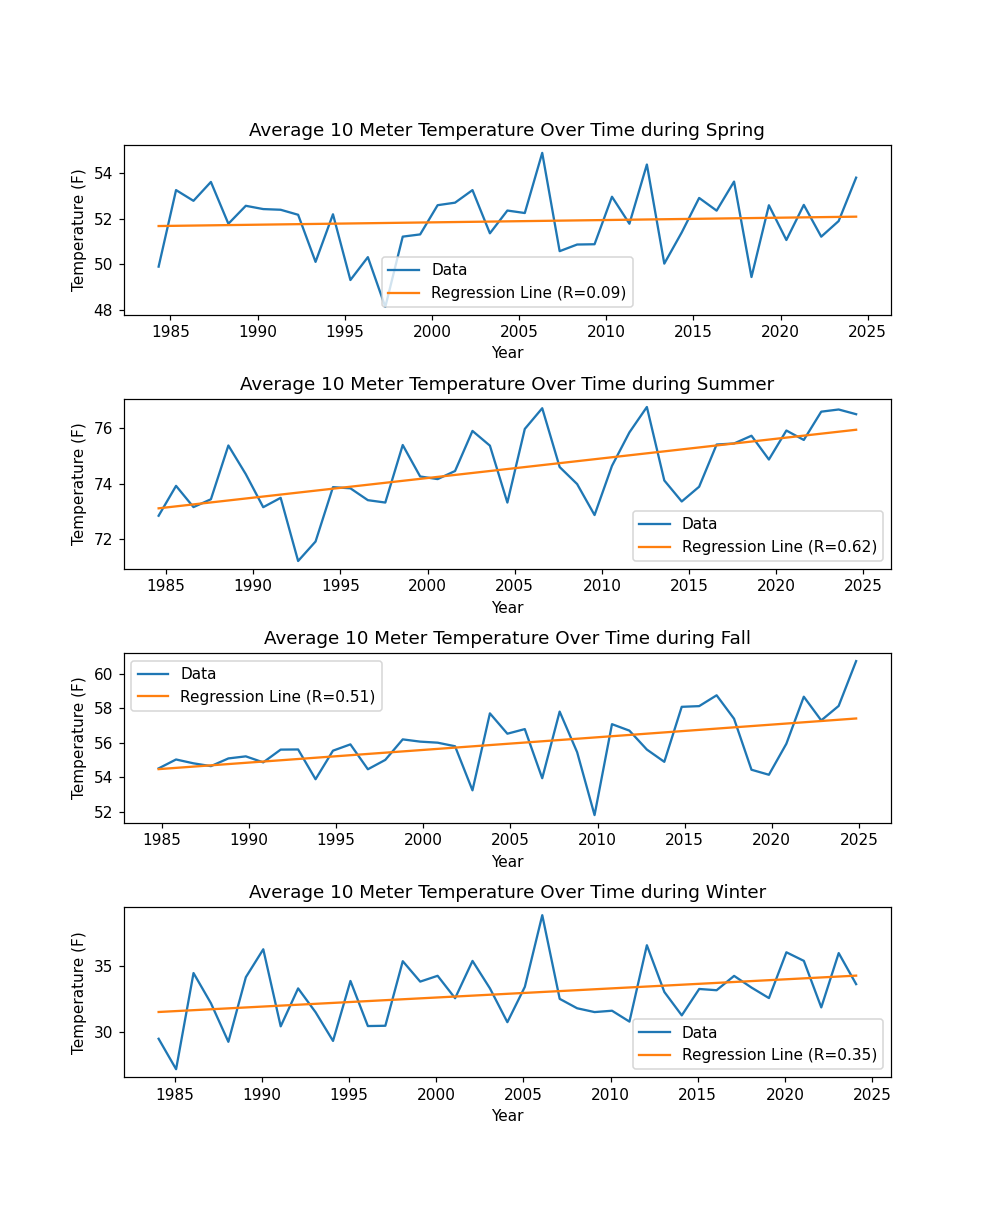


Spring: 
Slope: 2.819717291835693e-05
Intercept: 51.676329924650666
Correlation Coefficient (R): 0.08610722281515518
R-squared: 0.00741445382093878

Summer: 
Slope: 0.00019471907195028006
Intercept: 73.10751197296861
Correlation Coefficient (R): 0.6231468681222093
R-squared: 0.3883120192505181

Fall: 
Slope: 0.00020073725567405044
Intercept: 54.4685395042744
Correlation Coefficient (R): 0.5136491647872385
R-squared: 0.26383546448662776

Winter: 
Slope: 0.0001890595354014656
Intercept: 31.49107568784236
Correlation Coefficient (R): 0.35343647275364587
R-squared: 0.12491734027253866


In [19]:
'''

A correlation of +0.8 indicates a strong positive linear relationship. 
A correlation of -0.6 indicates a moderate negative linear relationship. 
A correlation of 0.2 indicates a weak positive linear relationship. 

'''

fig, axs = plt.subplots(4, 1,figsize=(9, 11))

df_temp_plot = df[['time','temp_10_meter']]# humidity
df_temp_plot = df_temp_plot.groupby(['time']).mean()

df_temp_plot.index = df_temp_plot.index.astype('datetime64[ns]')

df_temp_winter = df_temp_plot[df_temp_plot.index.month == 1] # seasonal bins
df_temp_spring = df_temp_plot[df_temp_plot.index.month == 4]
df_temp_summer = df_temp_plot[df_temp_plot.index.month == 7]
df_temp_fall = df_temp_plot[df_temp_plot.index.month == 10]

axs[0].set_xlabel("Year")
axs[0].set_ylabel("Temperature (F)")
axs[0].set_title("Average 10 Meter Temperature Over Time during Spring") 

axs[1].set_xlabel("Year")
axs[1].set_ylabel("Temperature (F)")
axs[1].set_title("Average 10 Meter Temperature Over Time during Summer")

axs[2].set_xlabel("Year")
axs[2].set_ylabel("Temperature (F)")
axs[2].set_title("Average 10 Meter Temperature Over Time during Fall")

axs[3].set_xlabel("Year")
axs[3].set_ylabel("Temperature (F)")
axs[3].set_title("Average 10 Meter Temperature Over Time during Winter")

#spring
dates = df_temp_spring.index .to_numpy()
values = df_temp_spring['temp_10_meter'].to_numpy()

df_average_TS = pd.DataFrame({'date': dates, 'value': values})
df_average_TS['date_num'] = (df_average_TS['date'] - df_average_TS['date'].min()).dt.days

reg_result = linregress(df_average_TS['date_num'], df_average_TS['value'])


slope = reg_result.slope
intercept = reg_result.intercept
r_value = reg_result.rvalue  # This is the correlation coefficient

print(f"\nSpring: ")
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"Correlation Coefficient (R): {r_value}")
print(f"R-squared: {r_value**2}")

regression_line = slope * df_average_TS['date_num'] + intercept
axs[0].plot(df_average_TS['date'].to_numpy(), df_temp_spring['temp_10_meter'].to_numpy(),'-', label='Data')
axs[0].plot(df_average_TS['date'].to_numpy(), regression_line.to_numpy(), label=f'Regression Line (R={r_value:.2f})') 


           
#summer
dates = df_temp_summer.index .to_numpy()
values = df_temp_summer['temp_10_meter'].to_numpy()

df_average_TS = pd.DataFrame({'date': dates, 'value': values})
df_average_TS['date_num'] = (df_average_TS['date'] - df_average_TS['date'].min()).dt.days
reg_result = linregress(df_average_TS['date_num'], df_average_TS['value'])


slope = reg_result.slope
intercept = reg_result.intercept
r_value = reg_result.rvalue  # This is the correlation coefficient


regression_line = slope * df_average_TS['date_num'] + intercept
print(f"\nSummer: ")
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"Correlation Coefficient (R): {r_value}")
print(f"R-squared: {r_value**2}")
axs[1].plot(df_average_TS['date'].to_numpy(), df_temp_summer['temp_10_meter'].to_numpy(),'-', label='Data')
axs[1].plot(df_average_TS['date'].to_numpy(), regression_line.to_numpy(), label=f'Regression Line (R={r_value:.2f})')  


#fall
dates = df_temp_fall.index .to_numpy()
values = df_temp_fall['temp_10_meter'].to_numpy()

df_average_TS = pd.DataFrame({'date': dates, 'value': values})
df_average_TS['date_num'] = (df_average_TS['date'] - df_average_TS['date'].min()).dt.days
reg_result = linregress(df_average_TS['date_num'], df_average_TS['value'])


slope = reg_result.slope
intercept = reg_result.intercept
r_value = reg_result.rvalue  # This is the correlation coefficient
regression_line = slope * df_average_TS['date_num'] + intercept
print(f"\nFall: ")
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"Correlation Coefficient (R): {r_value}")
print(f"R-squared: {r_value**2}")
axs[2].plot(df_average_TS['date'].to_numpy(), df_temp_fall['temp_10_meter'].to_numpy(),'-', label='Data')
axs[2].plot(df_average_TS['date'].to_numpy(), regression_line.to_numpy(), label=f'Regression Line (R={r_value:.2f})')    
    
    
#winter
dates = df_temp_winter.index .to_numpy()
values = df_temp_winter['temp_10_meter'].to_numpy()

df_average_TS = pd.DataFrame({'date': dates, 'value': values})
df_average_TS['date_num'] = (df_average_TS['date'] - df_average_TS['date'].min()).dt.days
reg_result = linregress(df_average_TS['date_num'], df_average_TS['value'])


slope = reg_result.slope
intercept = reg_result.intercept
r_value = reg_result.rvalue  # This is the correlation coefficient
regression_line = slope * df_average_TS['date_num'] + intercept
print(f"\nWinter: ")
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"Correlation Coefficient (R): {r_value}")
print(f"R-squared: {r_value**2}")
axs[3].plot(df_average_TS['date'].to_numpy(), df_temp_winter['temp_10_meter'].to_numpy(),'-', label='Data')
axs[3].plot(df_average_TS['date'].to_numpy(), regression_line.to_numpy(), label=f'Regression Line (R={r_value:.2f})')   


plt.subplots_adjust(wspace=0.4, hspace=0.5)
axs[0].legend()
axs[1].legend()
axs[2].legend()
axs[3].legend()
plt.show()


The regression model shows a moderate positive correlation of T10M over the 40 years during the seasons of summer and fall. The regression model explains a weak positive correlation of T10M during the winter. The correlation coefficient is not strong enough to explain any trend in T10M during the spring.

# 




# Conclusion:

Over the last 40 years the area of the contiguous United States has experienced a moderate change in climate. These changes take the form of moderate increases in land surface temperature, total column precipitable water, temperature at 2 meters, and temperature at 10 meters. There was a slight decrease in profile soil moisture. There was also very weak variation in precipitation. These effects resemble those proposed by the standard climate change predictions.

# Limitations:

My system has an Intel(R) Core(TM) i7-10750H CPU and 16.0 GB, this was barely enough handle the current amount of data. If possible to perform this analysis again on a stronger system I would probably want to analyze the data on a monthly or daily basis as well as broaden the scope of data to a larger area, leading to a more accurate analysis. Another limitation might be Jupyter itself as visualization and presentation might be better in other data analysis tools.

## Citation:


https://nasa-power.s3.amazonaws.com/merra2/temporal/power_merra2_monthly_temporal_utc.zarr/

Macpherson, B. (n.d.). Dashboard. NASA POWER | Prediction Of Worldwide Energy Resources. 
    https://power.larc.nasa.gov/dashboard/availability/

NASA POWER Cheatsheet. (n.d.). Gist. https://gist.github.com/abelcallejo/d68e70f43ffa1c8c9f6b5e93010704b8

NASA Prediction of Worldwide Energy Resources (POWER) was accessed 
    on 3/31/2025 from https://registry.opendata.aws/nasa-power.
    
What is climate change? (n.d.). NASA Science. https://science.nasa.gov/climate-change/what-is-climate-change/
